# Run the dynamic model for multiple locations and seasons

In [1]:
import os
import gc
import importlib
from copy import deepcopy
from pathlib import Path


import epiweeks
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

from inframind_proteus.outbreak_dynamics import RenewalSimulator, build_calibration_params_df, build_initial_infec_df
from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict, apply_include_exclude_logic, map_parallel_or_sequential_chunks, save_yaml_dict
)

In [2]:
class DiseaseTimeSeriesCache:

    def __init__(
            self,
            disease_cases_dir: Path,
            fname_fmt: str = "dengue_{uf}.csv"
    ):
        self.disease_cases_dir = Path(disease_cases_dir)
        self.fname_fmt = fname_fmt
        self.cache = {}

    def get(self, uf: str) -> pd.Series:
        if uf not in self.cache:
            cases_df = pd.read_csv(
                self.disease_cases_dir / self.fname_fmt.format(uf=uf),
                parse_dates=["date"],
            )
            cases_sr = cases_df.set_index("date")["value"]
            self.cache[uf] = cases_sr
        return self.cache[uf]



In [3]:
# Parameters of the multi-location code
# ================

base_config_path = Path("../../configs/prototype_run_dynamic_model.yaml")
base_config_dict = load_yaml_dict(Path("../../configs/prototype_run_dynamic_model.yaml"))
# cases_cache = DiseaseTimeSeriesCache(Path("../../data/disease/dengue_cases_uf_weekly"))

zero_date_epiweek = 41
sim_start_epiweek = 26  # Using zero_date minus at least 2x the maximum generation time in weeks
calibration_start_epiweek = 41
calibration_end_epiweek = 40  # Of the next year

use_location_ids = ["SP", "SE", "PI"]
exclude_location_ids = ["CE"]  # Just to test.
use_years = list(range(2018, 2024))



In [11]:

# ==========

# Load UF table to lookup locations
uf_table_df = pd.read_csv(Path("../../data/demographic/uf_table.csv"))

# Combine all years and locations to be run
location_ids = apply_include_exclude_logic(
    uf_table_df["uf"],
    include_list=use_location_ids,
    exclude_list=exclude_location_ids,
)
years = list(use_years)
location_year_index = pd.MultiIndex.from_product(
    [location_ids, years],
    names=["uf", "season"]
)


def run_simulation_for_location_year(location_year_tuple):
    location_id, year = location_year_tuple
    print(f"Iterating for {location_id} in {year}...")

    # Load again observations, since this function will run in parallel... not worth caching
    obserations_sr = DiseaseTimeSeriesCache(Path("../../data/disease/dengue_cases_uf_weekly")).get(location_id)

    # Create and modify the simulator and config object
    config_dict = deepcopy(base_config_dict)
    config_dict["location"]["location_id"] = location_id
    config_dict["simulation"]["population_size"] = uf_table_df.set_index("uf").loc[location_id, f"population_{year}"].item()
    _temporal = config_dict["temporal"]
    _temporal["zero_date"] = epiweeks.Week(year, zero_date_epiweek).startdate().isoformat()
    _temporal["sim_start"] = epiweeks.Week(year, sim_start_epiweek).startdate().isoformat()
    _temporal["calibration_start"] = epiweeks.Week(year, calibration_start_epiweek).startdate().isoformat()
    _temporal["calibration_end"] = epiweeks.Week(year + 1, calibration_end_epiweek).startdate().isoformat()

    simulator = RenewalSimulator.from_config_dict(config_dict)
    config = simulator.config

    # --- Build auxiliary data frames for simulations
    params_df = build_calibration_params_df(config.num_simulations, config.sampling)
    config.num_simulations = num_simulations = params_df.shape[0]  # Update in case sampling method changes number of simulations
    initial_infec_df = build_initial_infec_df(
        config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
        config.initial_infections
    )

    # Run
    # ======
    results = simulator.run(
        params_df=params_df,
        initial_infec_df=initial_infec_df,
        observations_sr=obserations_sr,
    )


    # [PROTOTYPE] Select best simulations via WIS
    wis_sr = results.scoring.summary["wis"]
    # -()- By fraction of number of simulations
    _nsim = wis_sr.shape[0]
    _frac = 0.001
    _n = np.ceil(_frac * _nsim).astype(int)

    selected_wis_sr = wis_sr.nsmallest(_n)

    # [PROTOTYPE]: Export results
    # =====
    _root = Path("../../")
    out_dir = _root / Path(config_dict["output"]["main_dir"]) / "calibration_results" / f"{location_id}_{year}"
    out_dir.mkdir(exist_ok=True, parents=True)

    save_yaml_dict(config_dict, out_dir / "config.yaml")
    params_df.to_csv(out_dir / "params.csv")
    results.scoring.summary.to_csv(out_dir / "scoring.csv")
    # results.case_beam_df.to_csv(out_dir / "case_beam_df.csv")  # TOOOOOOOOO heavy!
    # Export only selected trajectories (case beams) to save space
    results.case_beam_df.reset_index().set_index("i_simulation").loc[selected_wis_sr.index].to_csv(out_dir / "case_beam_selected_df.csv")
    print(f"Done: {out_dir}")


map_parallel_or_sequential_chunks(
    run_simulation_for_location_year,
    location_year_index,
    ncpus=4, chunksize=1
)
# run_simulation_for_location_year(("SP", 2023))
print("Done all simulations!")


Done all simulations!


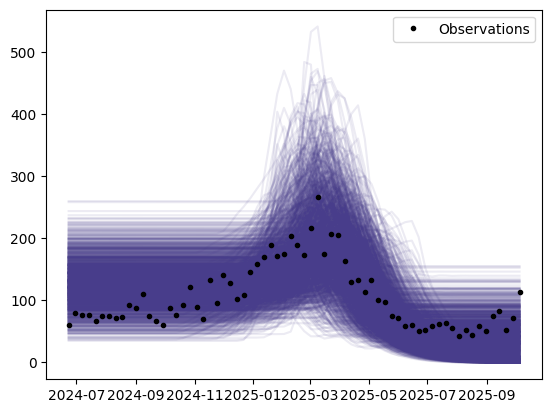

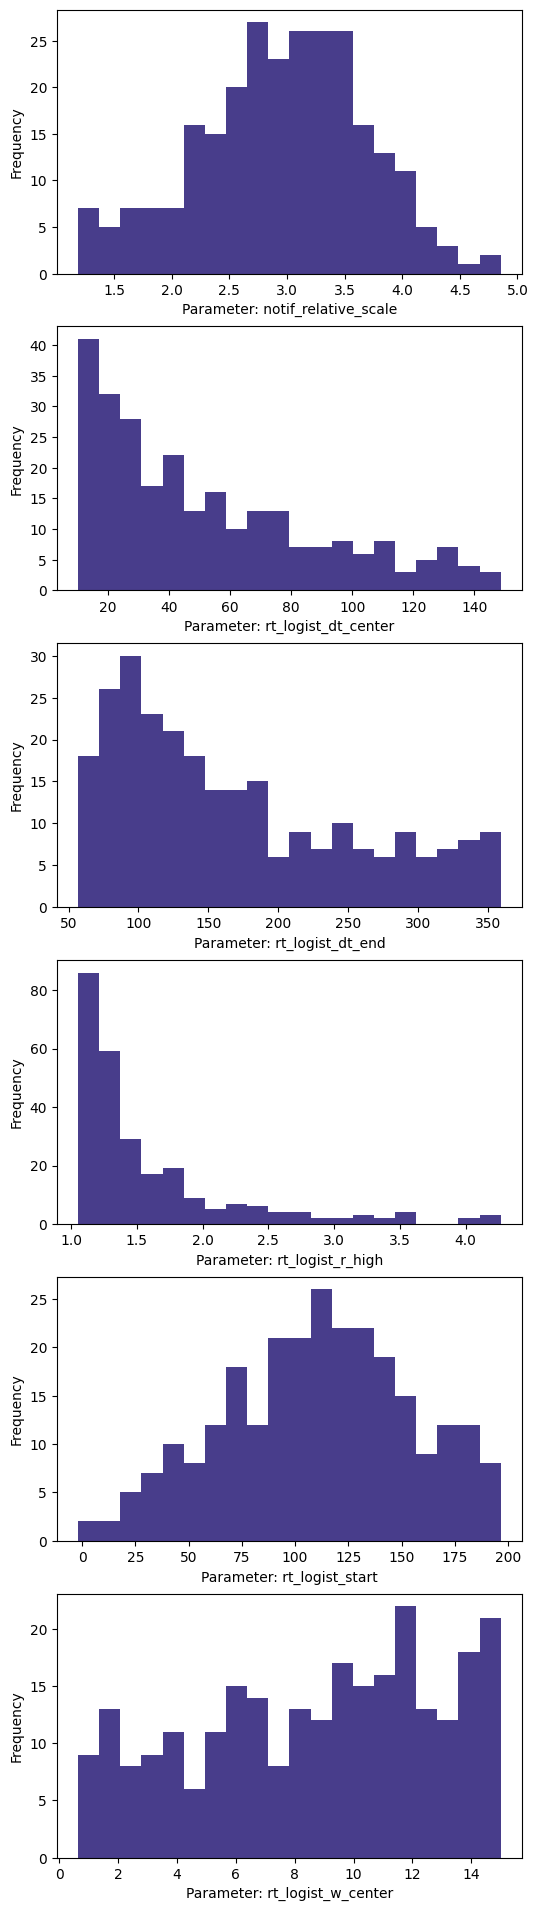

Average over selected parameter distributions: 
2024-06-23    126.835285
2024-06-30    126.835242
2024-07-07    126.833671
2024-07-14    126.830683
2024-07-21    126.828872
                 ...    
2025-09-07     35.782794
2025-09-14     35.614791
2025-09-21     35.480679
2025-09-28     35.375726
2025-10-05     35.295683
Length: 68, dtype: float64


In [5]:

# Try loading one
# ----
location_id, year = "AM", 2024
out_dir = Path(f"../../outputs/prototype_run_dynamic_model/calibration_results/{location_id}_{year}")

# ---
config_dict = load_yaml_dict(out_dir / "config.yaml")
config = RenewalSimulator.from_config_dict(config_dict).config
case_beam_selected_df = df =  pd.read_csv(out_dir / "case_beam_selected_df.csv.gz", index_col=["i_simulation", "quantile"])
df.columns = pd.to_datetime(df.columns)
params_df = pd.read_csv(out_dir / "params.csv.gz", index_col="i_simulation")
scoring_summary_df = pd.read_csv(out_dir / "scoring.csv.gz", index_col="i_simulation")
selected_i_simulations = case_beam_selected_df.index.get_level_values("i_simulation").unique()

observations_sr = DiseaseTimeSeriesCache(Path("../../data/disease/dengue_cases_uf_weekly")).get(location_id)

# # Rebuild the parameters data frame (unsafe if cross-machine)
# params_df = build_calibration_params_df(config.num_simulations, config.sampling)

# Visualize results
# ====================
with plt.rc_context():
    fig, ax = plt.subplots()

    # Simulation medians
    df = case_beam_selected_df
    ax.plot(df.T, color="darkslateblue", alpha=0.1)

    # Observations
    sr = observations_sr.loc[df.columns]
    ax.plot(sr, "o", ms=3, color="k", label="Observations")

    ax.legend()

    display(fig)

# Histogram of parameters
# ---------


sampled_param_names = list(config.sampling.param_ranges.keys())
best_sampled_params_df = params_df.loc[selected_i_simulations, sampled_param_names]

with plt.rc_context():
    fig, axes = plt.subplots(nrows=len(sampled_param_names), figsize=(6, 4 * len(sampled_param_names)))
    for i_param, param_name in enumerate(sampled_param_names):
        """"""
        ax: plt.Axes = axes[i_param]
        sr = best_sampled_params_df[param_name]
        ax.hist(sr, bins=20, color="darkslateblue")
        ax.set_xlabel(f"Parameter: {param_name}")
        ax.set_ylabel("Frequency")

    display(fig)

print(f"Average over selected parameter distributions: \n{case_beam_selected_df.mean(axis=0)}")



In [6]:
2 ** 19

524288